**Кластеризация латентных представлений для типизации режимов скважин**

**Цель**: Получить устойчивые кластеры в латентном пространстве автоэнкодера,
интерпретировать каждый кластер как типовой режим работы скважины и сравнить
качество разделения с baseline (EDA этап, Уровни 1–2).

**Входные данные**:
- models/ecn/model.pth   — лучший автоэнкодер ЭЦН (GRU, latent_dim=16)
- models/shgn/model.pth  — лучший автоэнкодер ШГН (GRU, latent_dim=64)
- data/processed/ecn_*.csv        — нормализованные временные ряды ЭЦН
- data/processed/shgn_*.csv       — нормализованные временные ряды ШГН

**Этапы**:
1. Загрузка моделей и данных
2. Кодирование всего датасета → матрица латентных векторов
3. Подбор числа кластеров (Elbow + Silhouette)
4. K-Means кластеризация + сохранение центроидов
5. Оценка качества: Silhouette, Davies-Bouldin, Calinski-Harabasz
6. Визуализация латентного пространства (PCA-2D / UMAP)
7. Интерпретация кластеров: декодирование центроидов → типовые профили
8. Сохранение артефактов кластеризации

**Выходные данные**:
- clustering/artifacts/ecn_kmeans.pkl   — K-Means модель ЭЦН
- clustering/artifacts/shgn_kmeans.pkl  — K-Means модель ШГН
- clustering/artifacts/ecn_labels.npy   — метки кластеров для всех окон ЭЦН
- clustering/artifacts/shgn_labels.npy  — метки кластеров для всех окон ШГН
- clustering/artifacts/ecn_latents.npy  — латентные векторы ЭЦН
- clustering/artifacts/shgn_latents.npy — латентные векторы ШГН

In [91]:
import logging
import pickle
import warnings
from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler, normalize
from torchinfo import summary
from umap import UMAP

# ==== 1. ЗАГРУЗКА МОДЕЛЕЙ И ДАННЫХ ====

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

In [ ]:
COLORS: dict[str, str] = {
    "primary": "#2E86AB",
    "secondary": "#A23B72",
    "accent": "#F18F01",
    "success": "#C73E1D",
    "neutral": "#6B7280",
    "cluster_0": "#2E86AB",
    "cluster_1": "#A23B72",
    "cluster_2": "#F18F01",
    "cluster_3": "#C73E1D",
}

CLUSTER_PALETTE: list[str] = [
    COLORS["cluster_0"],
    COLORS["cluster_1"],
    COLORS["cluster_2"],
    COLORS["cluster_3"],
]

plt.rcParams.update(
    {
        "figure.figsize": (15, 6),
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 100,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

FEATURE_COLUMNS: list[str] = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]

WINDOW_SIZES: dict[str, int] = {"ecn": 120, "shgn": 100}
STRIDES: dict[str, int] = {"ecn": 20, "shgn": 15}

N_CLUSTERS: dict[str, int] = {"ecn": 2, "shgn": 4}

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Устройство: {DEVICE}")

2026-02-22 21:08:57,550 - INFO - Устройство: cuda


In [36]:
def _windows_from_array(X: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    if len(X) < window_size:
        return np.empty((0, window_size, len(FEATURE_COLUMNS)), dtype=np.float32)
    w = sliding_window_view(X, window_shape=window_size, axis=0)[::stride]
    return np.transpose(w, (0, 2, 1)).astype(np.float32)


def _build_windows(df: pd.DataFrame, window_size: int, stride: int) -> np.ndarray:
    if "well" not in df.columns:
        return _windows_from_array(df[FEATURE_COLUMNS].to_numpy(dtype=np.float32), window_size, stride)
    parts = [
        _windows_from_array(g[FEATURE_COLUMNS].to_numpy(dtype=np.float32), window_size, stride)
        for _, g in df.groupby("well", sort=False)
    ]
    non_empty = [p for p in parts if len(p) > 0]
    return (
        np.concatenate(non_empty) if non_empty else np.empty((0, window_size, len(FEATURE_COLUMNS)), dtype=np.float32)
    )

In [37]:
def load_windows(prefix: str) -> tuple[np.ndarray, StandardScaler]:
    splits = {
        name: pd.read_csv(DATA_DIR / f"{prefix}_{name}.csv", parse_dates=["timestamp"])
        for name in ("train", "val", "test")
    }
    with open(DATA_DIR / f"scaler_{prefix}.pkl", "rb") as f:
        scaler: StandardScaler = pickle.load(f)

    window_size = WINDOW_SIZES[prefix]
    stride = STRIDES[prefix]

    parts = [_build_windows(splits[s], window_size, stride) for s in ("train", "val", "test")]
    X = np.concatenate([p for p in parts if len(p) > 0])
    logger.info(f"{prefix.upper()}: всего окон={X.shape[0]} | shape={X.shape}")
    return X, scaler

In [38]:
X_ecn, scaler_ecn = load_windows("ecn")
X_shgn, scaler_shgn = load_windows("shgn")

2026-02-22 20:34:21,742 - INFO - ECN: всего окон=2052 | shape=(2052, 120, 9)
2026-02-22 20:34:21,983 - INFO - SHGN: всего окон=8324 | shape=(8324, 100, 9)


# ==== 2. АРХИТЕКТУРА ====

In [59]:
class AttentionPool(nn.Module):
    def __init__(self, hidden_size: int) -> None:
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, seq_out: torch.Tensor) -> torch.Tensor:
        return (seq_out * torch.softmax(self.attn(seq_out), dim=1)).sum(dim=1)


class RNNAutoencoder(nn.Module):
    def __init__(
        self,
        rnn_cls: type[nn.RNNBase],
        input_dim: int,
        hidden_size: int,
        latent_dim: int,
        num_layers: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.is_lstm = rnn_cls is nn.LSTM
        eff_dropout = dropout if num_layers > 1 else 0.0

        self.encoder_rnn = rnn_cls(
            input_dim,  # type: ignore[call-arg]
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=eff_dropout,
            bidirectional=True,
        )
        self.attn_pool = AttentionPool(hidden_size * 2)
        self.encoder_fc = nn.Linear(hidden_size * 2, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, hidden_size * num_layers)
        self.decoder_rnn = rnn_cls(
            input_dim,  # type: ignore[call-arg]
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=eff_dropout,
        )
        self.output_fc = nn.Linear(hidden_size, input_dim)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.encoder_rnn(x)
        return self.encoder_fc(self.attn_pool(out))

    def _init_hidden(self, z: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor] | torch.Tensor:
        h = self.decoder_fc(z).view(z.size(0), self.num_layers, self.hidden_size).permute(1, 0, 2).contiguous()
        return (h, torch.zeros_like(h)) if self.is_lstm else h

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.encode(x)
        x_shifted = torch.cat([x[:, :1, :], x[:, :-1, :]], dim=1)
        out, _ = self.decoder_rnn(x_shifted, self._init_hidden(z))
        return self.output_fc(out), z


class GRUAutoencoder(RNNAutoencoder):
    def __init__(self, input_dim: int, hidden_size: int, latent_dim: int, num_layers: int, dropout: float) -> None:
        super().__init__(nn.GRU, input_dim, hidden_size, latent_dim, num_layers, dropout)

# ==== 3. ЗАГРУЗКА ВЕСОВ И КОДИРОВАНИЕ ====

In [67]:
def load_model(prefix: str) -> tuple[nn.Module, dict[str, Any]]:
    checkpoint: dict[str, Any] = torch.load(MODELS_DIR / prefix / "model.pth", map_location=DEVICE, weights_only=False)
    cfg = {
        "input_dim": len(FEATURE_COLUMNS),
        "hidden_size": 192,
        "num_layers": 2,
        "dropout": 0.15,
        "latent_dim": checkpoint["latent_dim"],
    }
    model = GRUAutoencoder(
        cfg["input_dim"], cfg["hidden_size"], cfg["latent_dim"], cfg["num_layers"], cfg["dropout"]
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    logger.info(f"{prefix.upper()}: latent_dim={checkpoint['latent_dim']} | metrics={checkpoint['metrics']}")
    return model, checkpoint

In [68]:
model_ecn, ckpt_ecn = load_model("ecn")
model_shgn, ckpt_shgn = load_model("shgn")

2026-02-22 20:50:25,238 - INFO - ECN: latent_dim=16 | metrics={'val_loss': 0.018270845037422562, 'val_mae': 0.06132933998378217, 'test_loss': 0.02111454480332256, 'test_mae': 0.07428136288003419}


2026-02-22 20:50:25,264 - INFO - SHGN: latent_dim=64 | metrics={'val_loss': 0.18097986589763, 'val_mae': 0.2948453098757674, 'test_loss': 0.18672066438026833, 'test_mae': 0.29404273350712284}


In [69]:
summary(
    model_ecn,
    input_size=(1, WINDOW_SIZES["ecn"], len(FEATURE_COLUMNS)),
    col_names=["input_size", "output_size", "num_params"],
    depth=3,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
GRUAutoencoder                           [1, 120, 9]               [1, 120, 9]               --
├─GRU: 1-1                               [1, 120, 9]               [1, 120, 384]             899,712
├─AttentionPool: 1-2                     [1, 120, 384]             [1, 384]                  --
│    └─Linear: 2-1                       [1, 120, 384]             [1, 120, 1]               385
├─Linear: 1-3                            [1, 384]                  [1, 16]                   6,160
├─Linear: 1-4                            [1, 16]                   [1, 384]                  6,528
├─GRU: 1-5                               [1, 120, 9]               [1, 120, 192]             339,264
├─Linear: 1-6                            [1, 120, 192]             [1, 120, 9]               1,737
Total params: 1,253,786
Trainable params: 1,253,786
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 

In [70]:
summary(
    model_shgn,
    input_size=(1, WINDOW_SIZES["shgn"], len(FEATURE_COLUMNS)),
    col_names=["input_size", "output_size", "num_params"],
    depth=3,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
GRUAutoencoder                           [1, 100, 9]               [1, 100, 9]               --
├─GRU: 1-1                               [1, 100, 9]               [1, 100, 384]             899,712
├─AttentionPool: 1-2                     [1, 100, 384]             [1, 384]                  --
│    └─Linear: 2-1                       [1, 100, 384]             [1, 100, 1]               385
├─Linear: 1-3                            [1, 384]                  [1, 64]                   24,640
├─Linear: 1-4                            [1, 64]                   [1, 384]                  24,960
├─GRU: 1-5                               [1, 100, 9]               [1, 100, 192]             339,264
├─Linear: 1-6                            [1, 100, 192]             [1, 100, 9]               1,737
Total params: 1,290,698
Trainable params: 1,290,698
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES)

In [71]:
def encode_dataset(model: nn.Module, X: np.ndarray, batch_size: int = 512) -> np.ndarray:
    latents: list[np.ndarray] = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = torch.from_numpy(X[start : start + batch_size]).float().to(DEVICE)
            z = cast(GRUAutoencoder, model).encode(batch)
            latents.append(z.cpu().numpy())
    return np.concatenate(latents)

In [72]:
Z_ecn = encode_dataset(model_ecn, X_ecn)
Z_shgn = encode_dataset(model_shgn, X_shgn)
logger.info(f"ЭЦН латенты: {Z_ecn.shape} | ШГН латенты: {Z_shgn.shape}")

2026-02-22 20:50:45,412 - INFO - ЭЦН латенты: (2052, 16) | ШГН латенты: (8324, 64)


In [74]:
Z_ecn = normalize(Z_ecn, norm="l2")
Z_shgn = normalize(Z_shgn, norm="l2")
logger.info("Латентные векторы L2-нормализованы")

2026-02-22 20:59:26,956 - INFO - Латентные векторы L2-нормализованы


# ==== 4. ПОДБОР ЧИСЛА КЛАСТЕРОВ ====

In [76]:
def plot_elbow_silhouette(Z: np.ndarray, pump_type: str, k_range: range = range(2, 9)) -> None:
    inertias: list[float] = []
    silhouettes: list[float] = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(Z)
        inertias.append(float(km.inertia_))
        silhouettes.append(float(silhouette_score(Z, labels, sample_size=min(5000, len(Z)))))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(list(k_range), inertias, marker="o", color=COLORS["primary"], linewidth=2)
    ax1.set_title("Elbow (инерция)")
    ax1.set_xlabel("Число кластеров k")
    ax1.set_ylabel("Inertia")

    ax2.plot(list(k_range), silhouettes, marker="o", color=COLORS["secondary"], linewidth=2)
    ax2.set_title("Silhouette Score")
    ax2.set_xlabel("Число кластеров k")
    ax2.set_ylabel("Silhouette")

    fig.suptitle(f"{pump_type}: подбор числа кластеров", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    best_k = list(k_range)[int(np.argmax(silhouettes))]
    logger.info(f"{pump_type}: лучший k по silhouette = {best_k} ({max(silhouettes):.4f})")

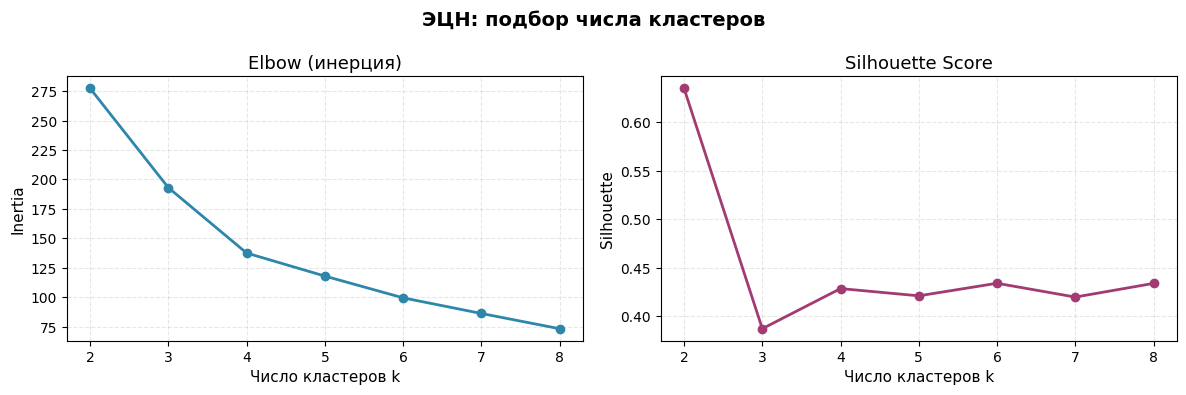

2026-02-22 21:02:21,659 - INFO - ЭЦН: лучший k по silhouette = 2 (0.6349)


In [77]:
plot_elbow_silhouette(Z_ecn, "ЭЦН")

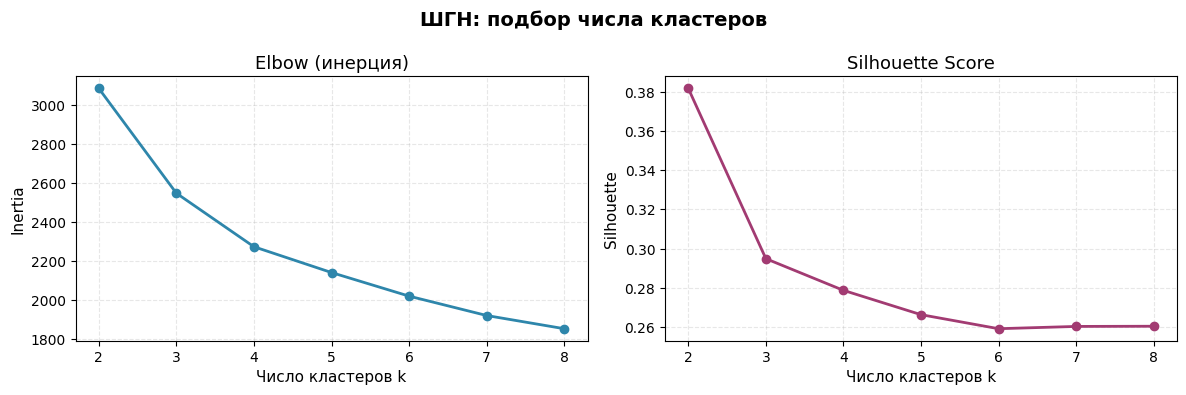

2026-02-22 21:08:16,297 - INFO - ШГН: лучший k по silhouette = 2 (0.3819)


In [79]:
plot_elbow_silhouette(Z_shgn, "ШГН")

# ==== 5. K-MEANS КЛАСТЕРИЗАЦИЯ ====

In [80]:
def fit_kmeans(Z: np.ndarray, n_clusters: int, pump_type: str) -> tuple[KMeans, np.ndarray]:
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = km.fit_predict(Z)

    sil = silhouette_score(Z, labels, sample_size=min(5000, len(Z)))
    db = davies_bouldin_score(Z, labels)
    ch = calinski_harabasz_score(Z, labels)

    logger.info(
        f"{pump_type} | k={n_clusters} | Silhouette={sil:.4f} | Davies-Bouldin={db:.4f} | Calinski-Harabasz={ch:.1f}"
    )
    return km, labels

In [83]:
km_ecn, labels_ecn = fit_kmeans(Z_ecn, N_CLUSTERS["ecn"], "ЭЦН")
km_shgn, labels_shgn = fit_kmeans(Z_shgn, N_CLUSTERS["shgn"], "ШГН")

2026-02-22 21:09:07,980 - INFO - ЭЦН | k=2 | Silhouette=0.6349 | Davies-Bouldin=0.4533 | Calinski-Harabasz=2327.6
2026-02-22 21:09:08,452 - INFO - ШГН | k=4 | Silhouette=0.2800 | Davies-Bouldin=1.6410 | Calinski-Harabasz=3289.4


# ==== 6. ВИЗУАЛИЗАЦИЯ ЛАТЕНТНОГО ПРОСТРАНСТВА ====

In [ ]:
def _reduce_to_2d(Z: np.ndarray, method: str) -> tuple[np.ndarray, str]:
    if method == "PCA":
        reducer = PCA(n_components=2, random_state=42)
        Z_2d = np.asarray(reducer.fit_transform(Z))
        explained = float(reducer.explained_variance_ratio_.sum())
        return Z_2d, f"PCA (объяснённая дисперсия: {explained:.1%})"

    reducer_umap = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        Z_2d = np.asarray(reducer_umap.fit_transform(Z))
    return Z_2d, "UMAP"


def plot_latent_space(Z: np.ndarray, labels: np.ndarray, pump_type: str, method: str = "PCA") -> None:
    Z_2d, subtitle = _reduce_to_2d(Z, method)
    n_clusters = len(np.unique(labels))

    fig, ax = plt.subplots(figsize=(10, 7))
    for k in range(n_clusters):
        mask = labels == k
        ax.scatter(
            Z_2d[mask, 0],
            Z_2d[mask, 1],
            c=CLUSTER_PALETTE[k % len(CLUSTER_PALETTE)],
            label=f"Кластер {k} (n={int(mask.sum())})",
            alpha=0.5,
            s=8,
            rasterized=True,
        )

    ax.set_title(f"{pump_type}: латентное пространство — {subtitle}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Компонента 1")
    ax.set_ylabel("Компонента 2")
    ax.legend(markerscale=3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

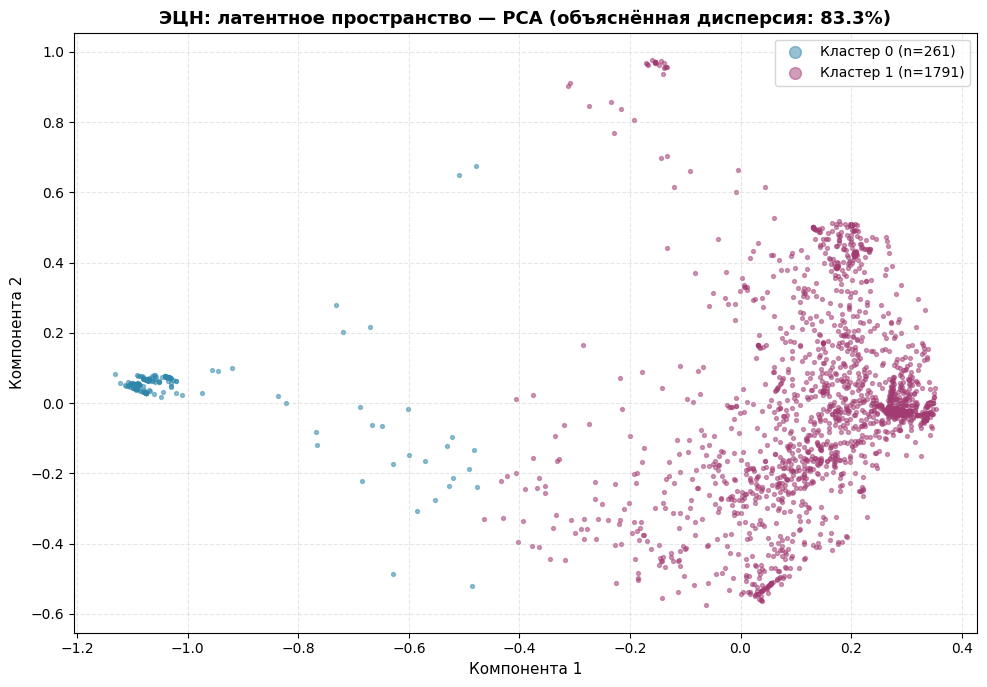

In [88]:
plot_latent_space(Z_ecn, labels_ecn, "ЭЦН", method="PCA")

c:\Users\aslan\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


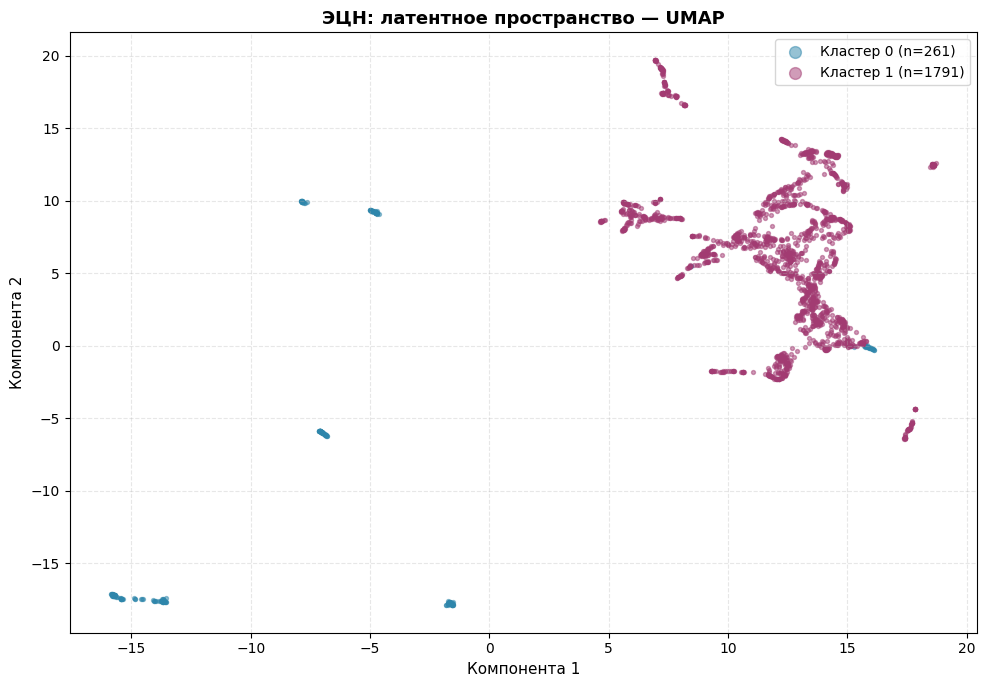

In [92]:
plot_latent_space(Z_ecn, labels_ecn, "ЭЦН", method="UMAP")

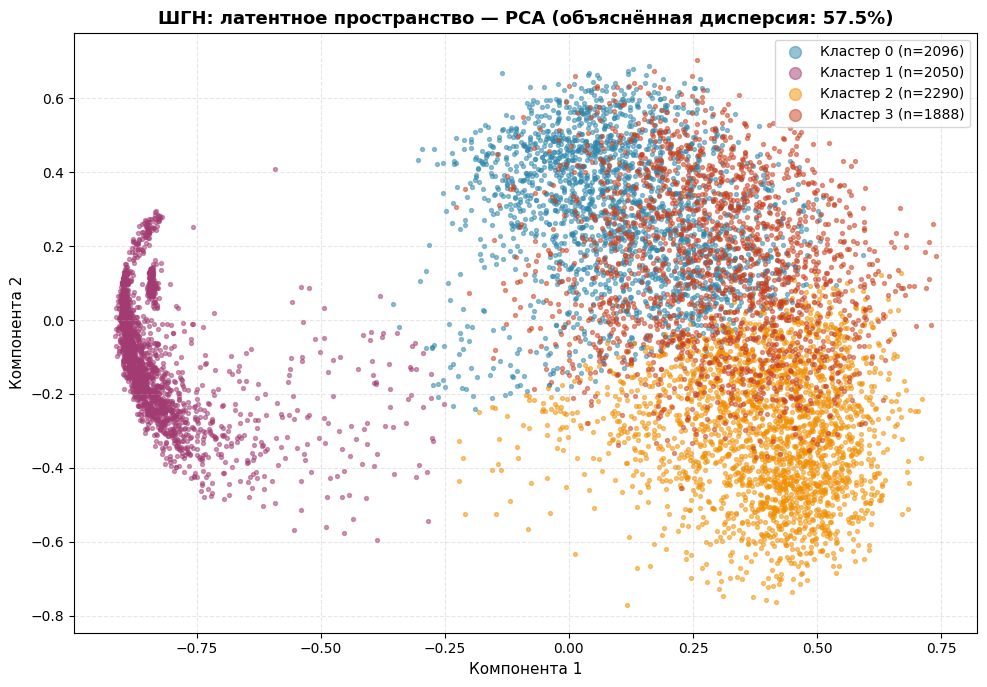

In [93]:
plot_latent_space(Z_shgn, labels_shgn, "ШГН", method="PCA")

c:\Users\aslan\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


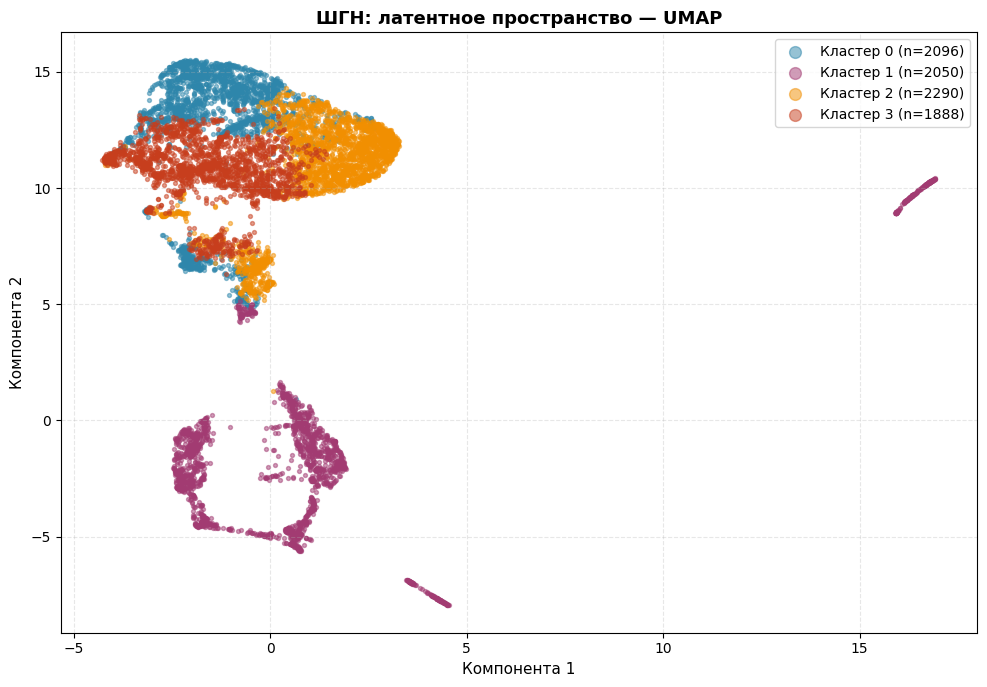

In [94]:
plot_latent_space(Z_shgn, labels_shgn, "ШГН", method="UMAP")

# ==== 7. ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ====

In [95]:
def decode_centroid(model: nn.Module, centroid: np.ndarray, window_size: int) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        z = torch.from_numpy(centroid).float().unsqueeze(0).to(DEVICE)

        if isinstance(model, RNNAutoencoder):
            h = model.decoder_fc(z).view(1, model.num_layers, model.hidden_size).permute(1, 0, 2).contiguous()
            hidden: tuple[torch.Tensor, torch.Tensor] | torch.Tensor = (h, torch.zeros_like(h)) if model.is_lstm else h
            input_dim = model.output_fc.out_features
            x_t = torch.zeros(1, 1, input_dim).to(DEVICE)
            outputs: list[torch.Tensor] = []
            for _ in range(window_size):
                out, hidden = model.decoder_rnn(x_t, hidden)
                x_t = model.output_fc(out)
                outputs.append(x_t)
            recon = torch.cat(outputs, dim=1)
        else:
            dummy_x = torch.zeros(1, window_size, model.output_fc.out_features).to(DEVICE)  # type: ignore[attr-defined]
            recon, _ = model.forward(dummy_x)

    return recon[0].cpu().numpy()

In [96]:
def plot_cluster_profiles(
    model: nn.Module,
    km: KMeans,
    pump_type: str,
    window_size: int,
    n_clusters: int,
) -> None:
    fig, axes = plt.subplots(n_clusters, len(FEATURE_COLUMNS), figsize=(22, 3 * n_clusters))

    for k in range(n_clusters):
        centroid: np.ndarray = km.cluster_centers_[k]
        profile = decode_centroid(model, centroid, window_size)
        steps = np.arange(window_size)

        for j, feature in enumerate(FEATURE_COLUMNS):
            ax = axes[k, j] if n_clusters > 1 else axes[j]
            ax.plot(steps, profile[:, j], color=CLUSTER_PALETTE[k % len(CLUSTER_PALETTE)], linewidth=1.5)
            if k == 0:
                ax.set_title(feature, fontsize=9, fontweight="bold")
            if j == 0:
                ax.set_ylabel(f"Кластер {k}", fontsize=9)

    fig.suptitle(f"{pump_type}: типовые профили кластеров (декодирование центроидов)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

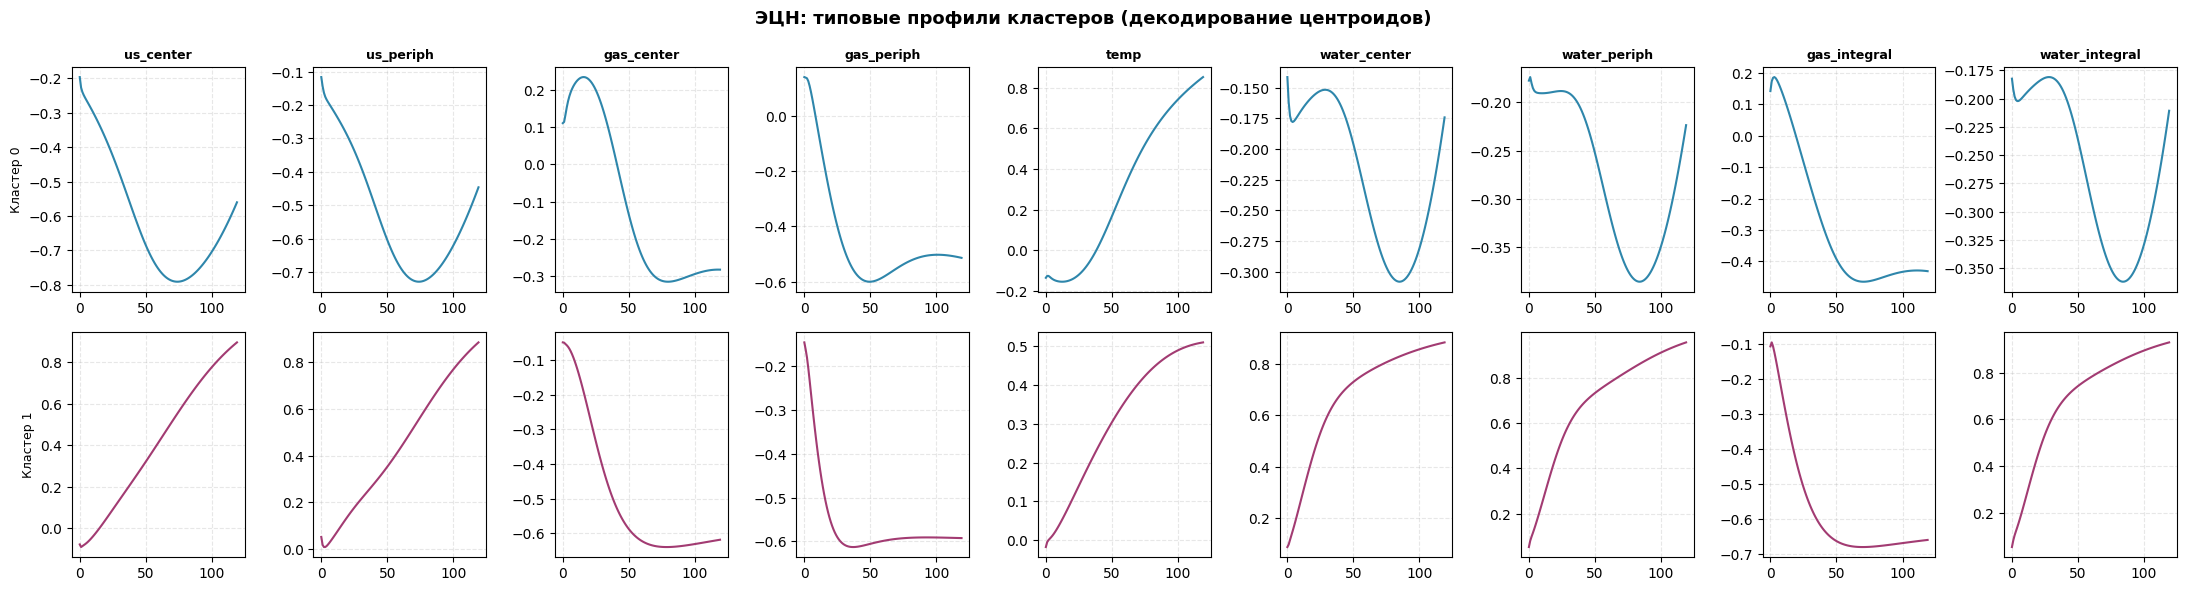

In [97]:
plot_cluster_profiles(model_ecn, km_ecn, "ЭЦН", WINDOW_SIZES["ecn"], N_CLUSTERS['ecn'])

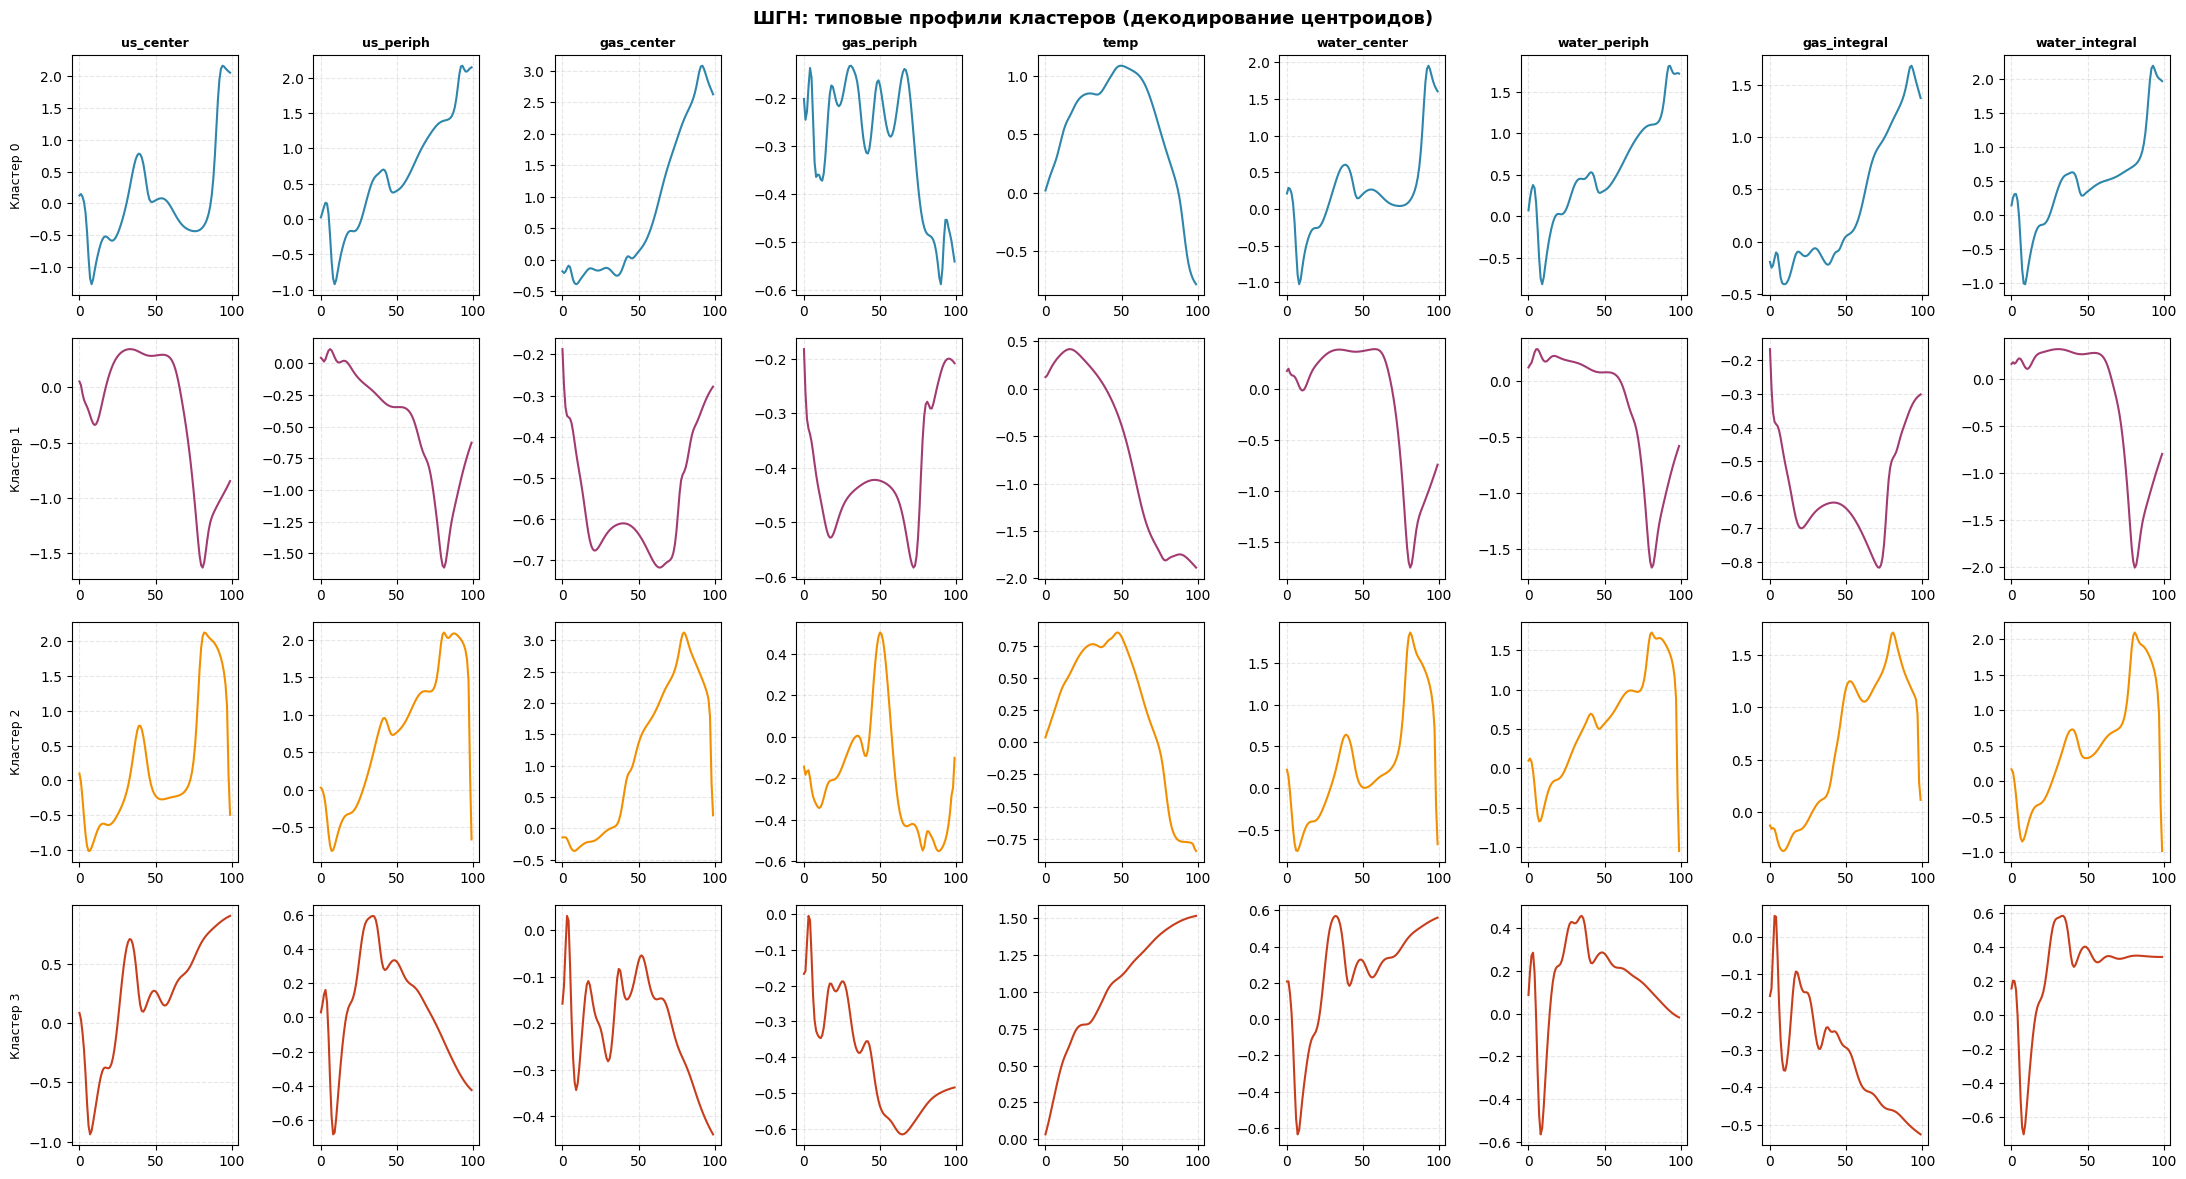

In [98]:
plot_cluster_profiles(model_shgn, km_shgn, "ШГН", WINDOW_SIZES["shgn"], N_CLUSTERS['shgn'])

# ==== 8. СТАТИСТИКА КЛАСТЕРОВ ====

In [99]:
def print_cluster_stats(Z: np.ndarray, labels: np.ndarray, km: KMeans, pump_type: str, n_clusters: int) -> None:
    rows: list[dict[str, Any]] = []
    for k in range(n_clusters):
        mask = labels == k
        z_k = Z[mask]
        dists = np.linalg.norm(z_k - km.cluster_centers_[k], axis=1)
        rows.append(
            {
                "Кластер": k,
                "Размер": mask.sum(),
                "Доля, %": f"{mask.mean() * 100:.1f}",
                "Среднее расстояние до центра": f"{dists.mean():.4f}",
                "Макс. расстояние": f"{dists.max():.4f}",
            }
        )

    df = pd.DataFrame(rows)
    styled = df.style.set_caption(f"{pump_type} — статистика кластеров").set_table_styles(
        [{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}]
    )
    display(styled)

In [100]:
print_cluster_stats(Z_ecn, labels_ecn, km_ecn, "ЭЦН", N_CLUSTERS["ecn"])

,Кластер,Размер,"Доля, %",Среднее расстояние до центра,Макс. расстояние
0,0,261,12.7,0.2016,0.8852
1,1,1791,87.3,0.3313,1.1379


In [101]:
print_cluster_stats(Z_shgn, labels_shgn, km_shgn, "ШГН", N_CLUSTERS["shgn"])

,Кластер,Размер,"Доля, %",Среднее расстояние до центра,Макс. расстояние
0,0,2096,25.2,0.5447,0.8777
1,1,2050,24.6,0.2970,0.8373
2,2,2290,27.5,0.5763,0.9740
3,3,1888,22.7,0.5738,0.9314


# ==== 9. СОХРАНЕНИЕ АРТЕФАКТОВ ====

In [104]:
def save_artifacts(
    prefix: str,
    km: KMeans,
    labels: np.ndarray,
    Z: np.ndarray,
    n_clusters: int,
) -> None:
    artifact_dir = MODELS_DIR / prefix
    artifact_dir.mkdir(exist_ok=True, parents=True)

    with open(artifact_dir / "kmeans.pkl", "wb") as f:
        pickle.dump(km, f)

    np.save(artifact_dir / "labels.npy", labels)
    np.save(artifact_dir / "latents.npy", Z)

    logger.info(f"{prefix.upper()} артефакты сохранены → {artifact_dir.absolute()}")
    logger.info(f"  kmeans: {n_clusters} кластеров | labels: {labels.shape} | latents: {Z.shape}")

In [105]:
save_artifacts("ecn", km_ecn, labels_ecn, Z_ecn, N_CLUSTERS["ecn"])
save_artifacts("shgn", km_shgn, labels_shgn, Z_shgn, N_CLUSTERS["shgn"])

2026-02-22 21:33:00,222 - INFO - ECN артефакты сохранены → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\ecn
2026-02-22 21:33:00,223 - INFO -   kmeans: 2 кластеров | labels: (2052,) | latents: (2052, 16)
2026-02-22 21:33:00,228 - INFO - SHGN артефакты сохранены → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\shgn
2026-02-22 21:33:00,229 - INFO -   kmeans: 4 кластеров | labels: (8324,) | latents: (8324, 64)
